In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
print("torch version: ",torch.__version__)

torch version:  2.10.0+cpu


In [8]:
img1 = cv2.imread("test.jpg")
img2 = cv2.imread("test2.png")

img1Gray = cv2.imread("test.jpg", cv2.IMREAD_GRAYSCALE)
img2Gray = cv2.imread("test2.jpg", cv2.IMREAD_GRAYSCALE)

(np.float64(-0.5), np.float64(1023.5), np.float64(1535.5), np.float64(-0.5))

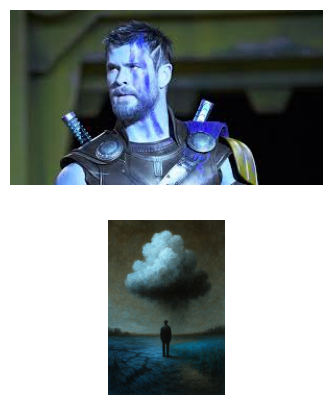

In [13]:
fig, axs = plt.subplots(2,1, figsize = (10,5))
axs[0].imshow(img1)
axs[0].axis('off')

axs[1].imshow(img2)
axs[1].axis('off')

In [14]:
img1.shape, img2.shape

((168, 300, 3), (1536, 1024, 3))

Shape of Normalized image 1 tensor: torch.Size([168, 300, 3])
Normalized Min pixel value: 0.0
Normalized Max pixel value: 1.0


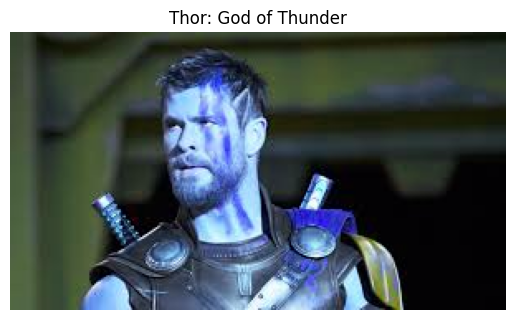

In [16]:
# convert the images to PyTorch tensors and normalize.
img1_tensor = torch.tensor(img1, dtype= torch.float32) / 255.0

print(f"Shape of Normalized image 1 tensor: {img1_tensor.shape}")
print(f"Normalized Min pixel value: {torch.min(img1_tensor)}\nNormalized Max pixel value: {torch.max(img1_tensor)}")

plt.imshow(img1_tensor)
plt.title("Thor: God of Thunder")
plt.axis("off")
plt.show()

In [21]:
img3 = cv2.imread("test_copy.jpg")
img3_tensor= torch.tensor(img3, dtype=torch.float32) / 255.0
img3_tensor.shape

torch.Size([168, 300, 3])

In [23]:
# creating input batch
batch_tensor = torch.stack([img1_tensor, img3_tensor])

print(f"Batch tensor shape: {batch_tensor.shape} where [N, C, H, W]")

Batch tensor shape: torch.Size([2, 168, 300, 3]) where [N, C, H, W]


In [25]:
# In Pytorch, image tensors typically follow the shape convension [N, C, H, W] unlike tensorflow follows [N, H, W, C]. therefore, we need to bring the color channel to the second dimension. This can be achieved using either torch.view() or torch.permute().

batch_input = batch_tensor.permute(0,3,1,2)
print(f"Batch tensor shape: {batch_tensor.shape}")

Batch tensor shape: torch.Size([2, 168, 300, 3])
